# Manutenção Preditiva de Motores (NASA C-MAPSS / FD001)

Prevê a **Vida Útil Restante (RUL)** de motores turbofan a partir de leituras de sensores — um problema de **regressão supervisionada**.

Fluxo: EDA → engenharia do alvo RUL → modelagem (baseline + ensembles) → avaliação honesta. A lógica vive no pacote `src/`; aqui mostramos o passo a passo.

## 0. Setup e imports

In [1]:
import sys
from pathlib import Path

# Permite importar o pacote `src` rodando o Jupyter da raiz OU de notebooks/.
RAIZ = Path.cwd()
if not (RAIZ / 'src').exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import pandas as pd

from src.data import SENSORS, carregar_rul, carregar_serie
from src.features import adicionar_rul, colunas_constantes, features_uteis

DATA = RAIZ / 'data'
FIG = RAIZ / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
print('Setup OK')

Setup OK


## 1. Leitura e EDA

Cada linha é um ciclo de operação de um motor. No treino, todo motor roda **até falhar**.

In [2]:
treino = carregar_serie(DATA / 'train_FD001.txt')
print(f'{treino.unit_number.nunique()} motores | {len(treino)} leituras | {treino.shape[1]} colunas')
treino.head()

100 motores | 20631 leituras | 26 colunas


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### 1.1 Distribuição da duração de vida
Quantos ciclos cada motor dura até a falha?

{'min': 128.0, 'mean': 206.3, 'max': 362.0}


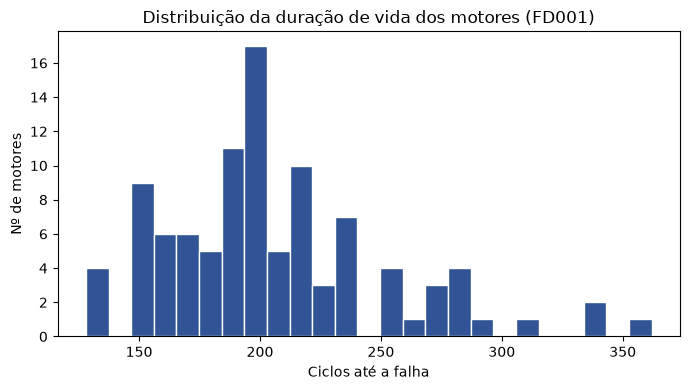

In [3]:
vida = treino.groupby('unit_number').time_in_cycles.max()
print(vida.describe()[['min', 'mean', 'max']].round(1).to_dict())
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(vida, bins=25, color='#305496', edgecolor='white')
ax.set_xlabel('Ciclos até a falha'); ax.set_ylabel('Nº de motores')
ax.set_title('Distribuição da duração de vida dos motores (FD001)')
fig.tight_layout(); fig.savefig(FIG / 'distribuicao_vida.png', dpi=120); plt.show()

### 1.2 Quais sensores DEGRADAM ao longo da vida?

Adicionamos o alvo RUL e medimos a **correlação de cada sensor com a RUL**. Sensores com |correlação| alta carregam o sinal de degradação; os de correlação ~0 são constantes/ruído e serão descartados.

In [4]:
treino_rul = adicionar_rul(treino)
constantes = colunas_constantes(treino_rul)
corr = treino_rul[SENSORS].corrwith(treino_rul.RUL).dropna().sort_values()
print('Sensores constantes (descartados):', constantes)
print('\nTop sensores por correlação com a RUL:')
print(corr.reindex(corr.abs().sort_values(ascending=False).index).head(8).round(3))

Sensores constantes (descartados): ['op_setting_3', 'sensor_1', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'sensor_5']

Top sensores por correlação com a RUL:
sensor_11   -0.696
sensor_4    -0.679
sensor_12    0.672
sensor_7     0.657
sensor_15   -0.643
sensor_21    0.636
sensor_20    0.629
sensor_2    -0.606
dtype: float64


/home/david-alves-de-oliveira/Documentos/TI/git/projeto 4 /manutencao-preditiva-turbofan/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/david-alves-de-oliveira/Documentos/TI/git/projeto 4 /manutencao-preditiva-turbofan/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


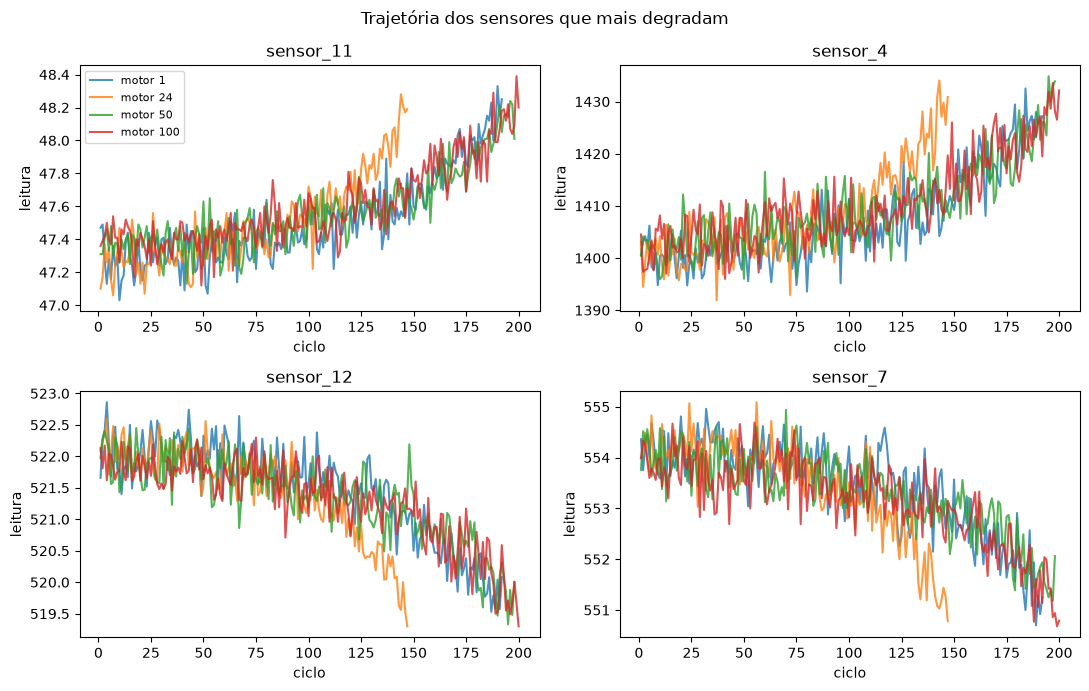

In [5]:
# Trajetória dos 4 sensores mais informativos para alguns motores.
mais_informativos = corr.abs().sort_values(ascending=False).head(4).index.tolist()
motores = [1, 24, 50, 100]
fig, axs = plt.subplots(2, 2, figsize=(11, 7))
for ax, sensor in zip(axs.ravel(), mais_informativos):
    for m in motores:
        sub = treino_rul[treino_rul.unit_number == m]
        ax.plot(sub.time_in_cycles, sub[sensor], label=f'motor {m}', alpha=0.8)
    ax.set_title(sensor); ax.set_xlabel('ciclo'); ax.set_ylabel('leitura')
axs[0, 0].legend(fontsize=8)
fig.suptitle('Trajetória dos sensores que mais degradam')
fig.tight_layout(); fig.savefig(FIG / 'trajetoria_sensores.png', dpi=120); plt.show()

**Leitura:** os sensores acima têm tendência clara (sobem ou descem) conforme o motor se aproxima da falha — é deles que o modelo extrai o sinal. Os sensores listados como constantes não variam e não ajudam.

## 2. Modelagem e avaliação

Reusamos o pipeline do pacote (`src/model.py`): baseline linear + Random Forest + Gradient Boosting + um GridSearch pequeno no RF. Métrica em **ciclos**.

In [6]:
from src.model import main as treinar_e_avaliar
resultados = treinar_e_avaliar()
pd.DataFrame(resultados).T.round(2).sort_values('RMSE')

Motores no treino: 100 | leituras: 20631
Colunas constantes descartadas (7): ['op_setting_3', 'sensor_1', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'sensor_5']
Features usadas (17): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'op_setting_1', 'op_setting_2']

Baseline (Linear)     RMSE= 31.99  MAE= 25.47  (ciclos)


Random Forest         RMSE= 33.93  MAE= 24.81  (ciclos)


Gradient Boosting     RMSE= 32.60  MAE= 23.54  (ciclos)

GridSearch (Random Forest, 3-fold)...


  melhores params: {'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 400}
  Random Forest (tuned)  RMSE= 31.93  MAE= 23.93

Melhor modelo: Random Forest (tuned) (RMSE=31.93 ciclos)


Figuras salvas em /home/david-alves-de-oliveira/Documentos/TI/git/projeto 4 /manutencao-preditiva-turbofan/reports/figures


,RMSE,MAE
Random Forest (tuned),31.93,23.93
Baseline (Linear),31.99,25.47
Gradient Boosting,32.60,23.54
Random Forest,33.93,24.81


### 2.1 Diagnóstico do melhor modelo
As figuras abaixo (geradas pelo pipeline) mostram previsto×real, os resíduos e **onde** o erro se concentra.

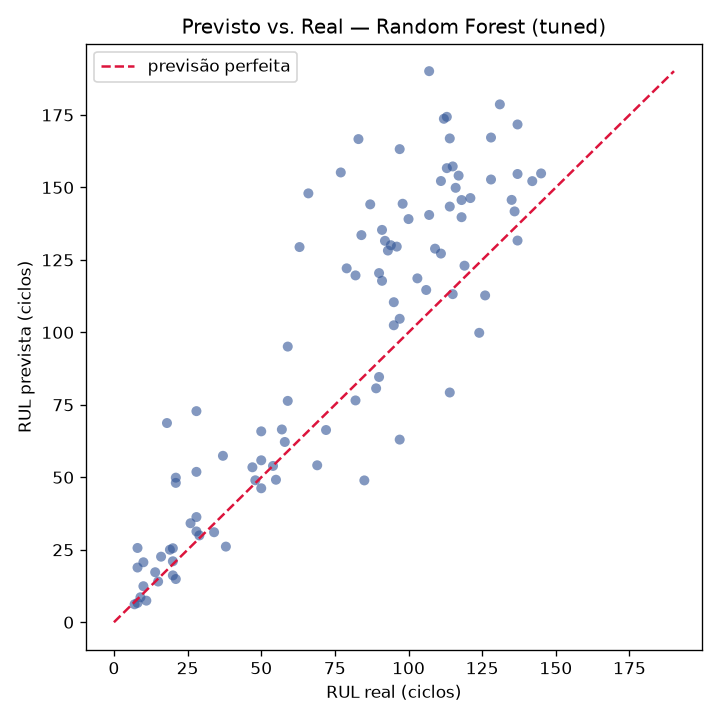

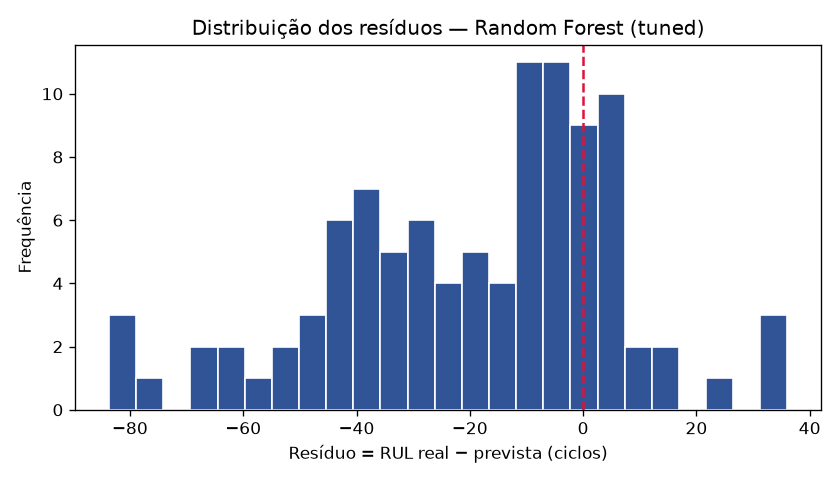

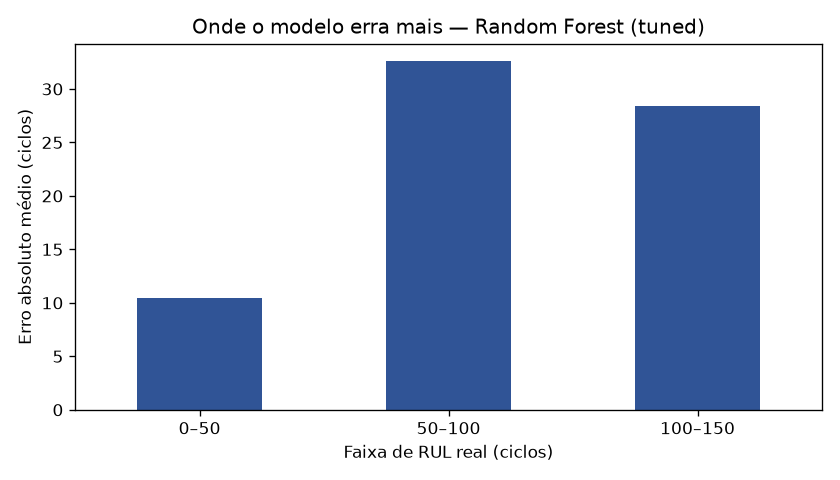

In [7]:
from IPython.display import Image, display
for nome in ['previsto_vs_real.png', 'residuos.png', 'erro_por_faixa.png']:
    display(Image(filename=str(FIG / nome)))

## 3. Conclusão

- O erro se concentra nos motores **longe da falha** (RUL alto): com a janela de sensores ainda "saudável", o sinal de degradação é fraco e o modelo tende a subestimar a RUL.
- Próximo passo padrão na literatura: **limitar a RUL** (ex.: clipar em ~125 ciclos), refletindo que muito antes da falha a RUL não é prevista pelos sensores. Isso costuma reduzir bastante o RMSE.
- Os números do README vêm **desta execução real**, sem ajuste cosmético.